## IMPORT THE LIBRARAIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    make_scorer
)


from sklearn.svm import SVC

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

## READ THE DATA


In [2]:
df = pd.read_csv("airline_passenger_satisfaction.csv")

df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


## SHAPE OF DATASE


In [3]:
print(df.shape)

(129880, 24)


## INFO OF DATASET


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

### DESCRIBE THE DATA 

In [5]:
df.describe().T.head(5)

,count,mean,std,min,25%,50%,75%,max
ID,129880.0,64940.500000,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.427957,15.119360,7.0,27.00,40.0,51.00,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.00,844.0,1744.00,4983.0
Departure Delay,129880.0,14.713713,38.071126,0.0,0.00,0.0,12.00,1592.0
Arrival Delay,129487.0,15.091129,38.465650,0.0,0.00,0.0,13.00,1584.0


## NULL VALUE CHECKS

In [6]:
print(df.isnull().sum())

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

## CHECK THE DUPLICATED VALUE

In [7]:
df.duplicated().sum()

np.int64(0)

## DROP THE COLUMN 

In [8]:
df.drop("ID", axis=1, inplace=True)

## FILL THE ARRIVAL DELAY COLUMN WITH MEDIAN


In [9]:
median_delay = df['Arrival Delay'].median()
df['Arrival Delay'] = df['Arrival Delay'].fillna(median_delay)

## TARGET CLASS DISTRIBUTION

Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


C:\Users\Zain\AppData\Local\Temp\ipykernel_5520\2760867540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Satisfaction", data=df, palette=["#e74c3c", "#2ecc71"])


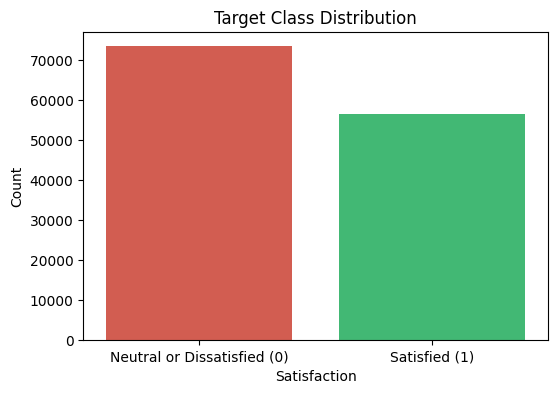

In [10]:
target_counts = df["Satisfaction"].value_counts()
print(target_counts)

plt.figure(figsize=(6,4))
sns.countplot(x="Satisfaction", data=df, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0,1], ["Neutral or Dissatisfied (0)", "Satisfied (1)"])
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.show()



## UNIVARIATE ANALYSIS 

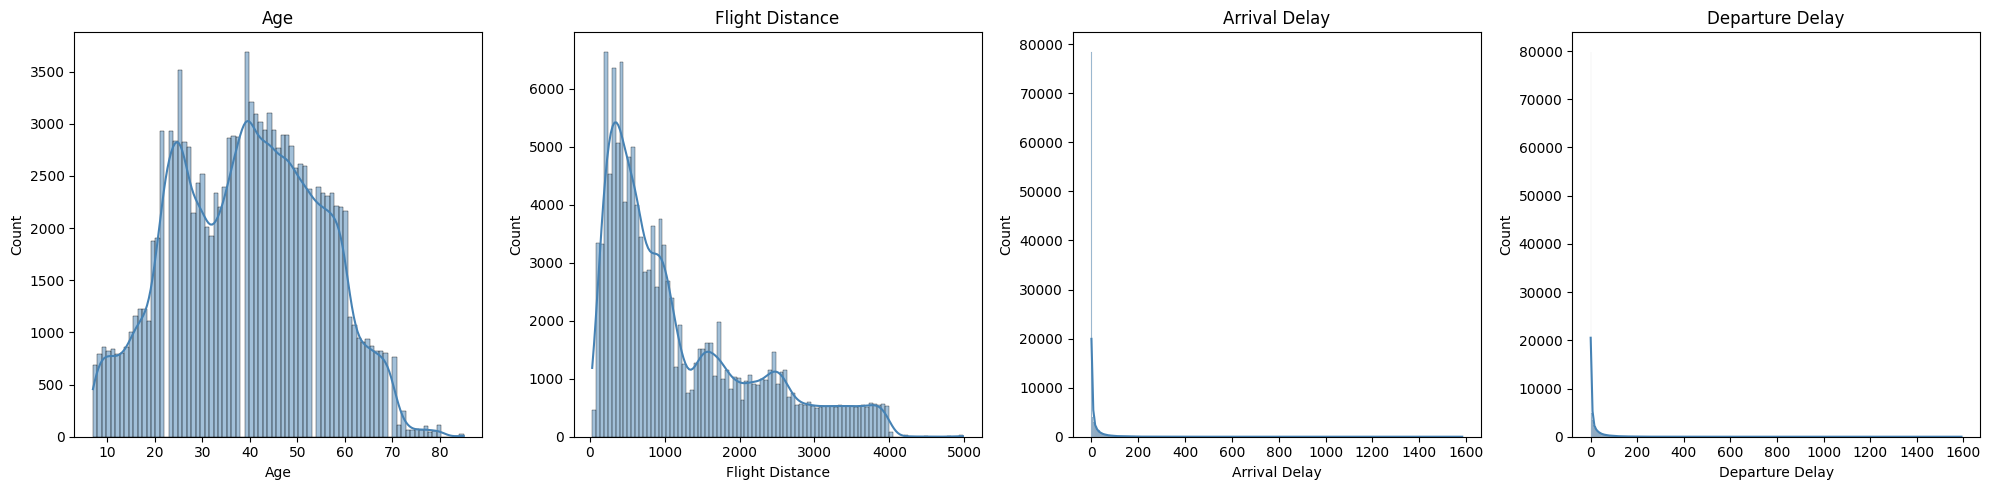

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sample_features = [
    'Age',
    'Flight Distance',
    'Arrival Delay',
    'Departure Delay'
]

for ax, feature in zip(axes, sample_features):
    sns.histplot(df[feature], kde=True, ax=ax, color="steelblue")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## BIVARIATE ANALYSIS

C:\Users\Zain\AppData\Local\Temp\ipykernel_5520\1180294968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Zain\AppData\Local\Temp\ipykernel_5520\1180294968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Zain\AppData\Local\Temp\ipykernel_5520\1180294968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Zain\AppData\Local\Temp\ipykernel_5520\1180294968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

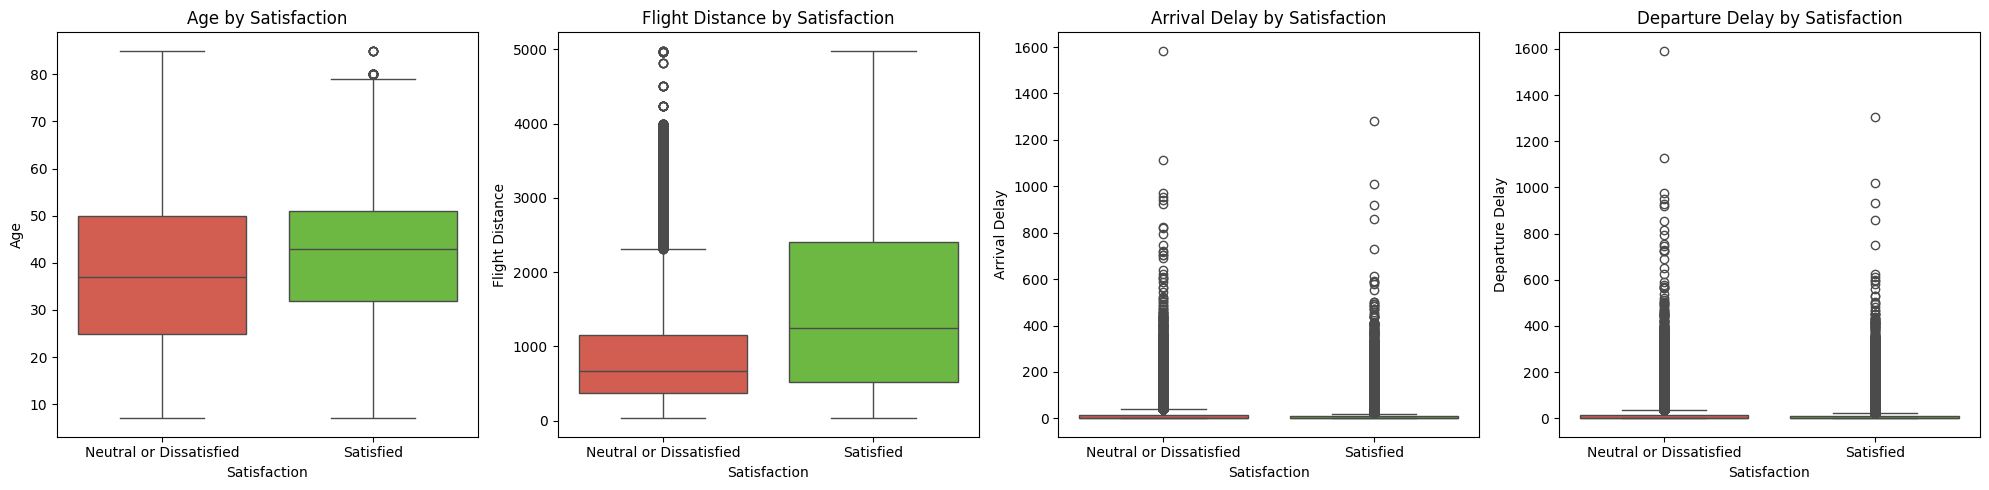

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

features = ["Age", "Flight Distance", "Arrival Delay", "Departure Delay"]

for ax, feature in zip(axes, features):
    sns.boxplot(
        x="Satisfaction",
        y=feature,
        data=df,
        ax=ax,
        palette=["#e74c3c", "#68cc2e"]
    )
    ax.set_title(f"{feature} by Satisfaction")
    ax.set_xlabel("Satisfaction")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## CORRELATION 

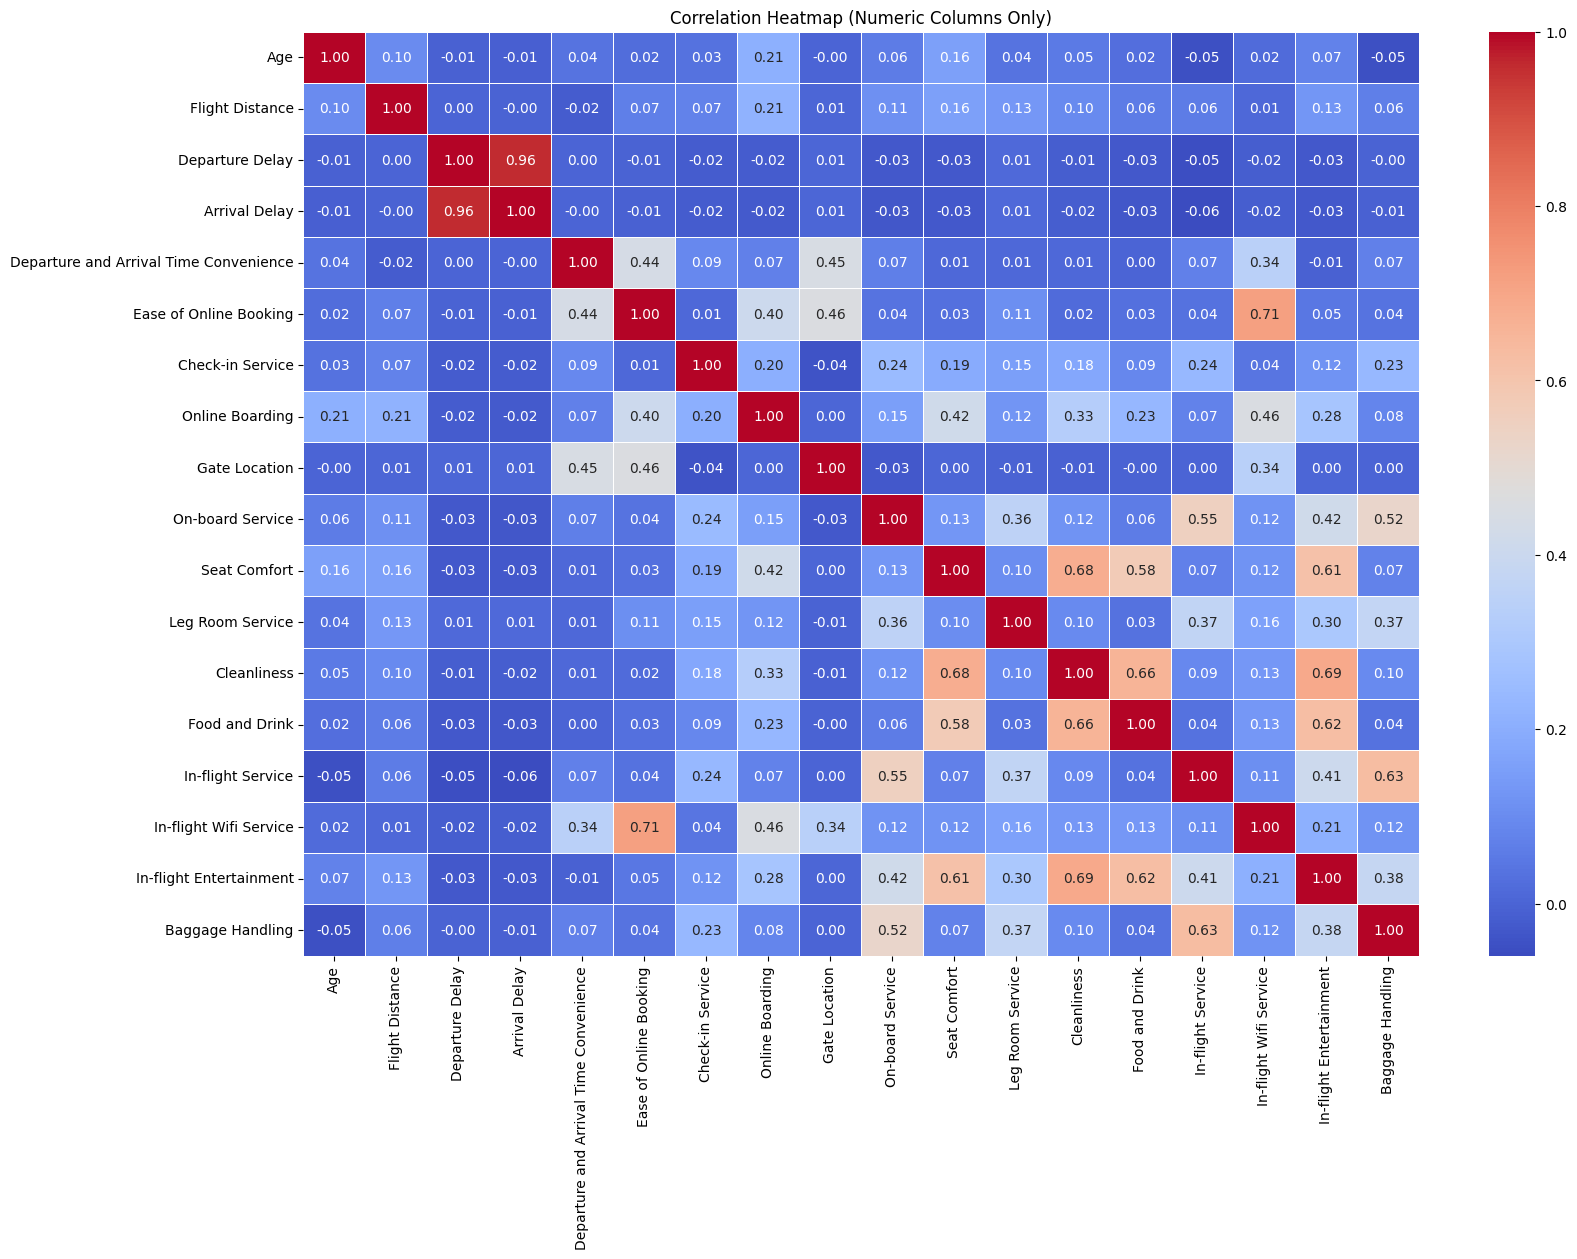

In [13]:

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

## OUTLIERS DETECTION

In [14]:

sample_cols = ["Age", "Flight Distance", "Arrival Delay","Departure Delay"]


def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((series < lower) | (series > upper)).sum()

# Count outliers for the selected columns
outlier_summary = df[sample_cols].apply(count_outliers_iqr)

# Print the result
print("Outlier Count (Selected Columns):")
print(outlier_summary)

Outlier Count (Selected Columns):
Age                    0
Flight Distance     2855
Arrival Delay      17492
Departure Delay    18098
dtype: int64


In [52]:
le =  LabelEncoder()

df['Satisfaction'] = le.fit_transform(df['Satisfaction'])

## TRAIN_TEST_SPLIT

In [54]:
X = df.drop("Satisfaction", axis=1)
y = df["Satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True))

Training Data Shape: (103904, 22)
Testing Data Shape: (25976, 22)

Training Target Distribution:
Satisfaction
0    0.565541
1    0.434459
Name: proportion, dtype: float64

Testing Target Distribution:
Satisfaction
0    0.565522
1    0.434478
Name: proportion, dtype: float64


## NORMALIZATION 

In [56]:
scaler = MinMaxScaler()


numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns


print("Before Normalization (Train):")
print(X_train[numeric_cols].describe().loc[["min", "max"]].T)


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


print("\nAfter Normalization (Train):")
print(X_train[numeric_cols].describe().loc[["min", "max"]].T)

Before Normalization (Train):
                                         min     max
Gender                                   0.0     0.0
Age                                      7.0    85.0
Customer Type                            0.0     1.0
Type of Travel                           0.0     1.0
Class                                    0.0     2.0
Flight Distance                         31.0  4983.0
Departure Delay                          0.0  1592.0
Arrival Delay                            0.0  1584.0
Departure and Arrival Time Convenience   0.0     5.0
Ease of Online Booking                   0.0     5.0
Check-in Service                         1.0     5.0
Online Boarding                          0.0     5.0
Gate Location                            1.0     5.0
On-board Service                         0.0     5.0
Seat Comfort                             1.0     5.0
Leg Room Service                         0.0     5.0
Cleanliness                              0.0     5.0
Food and Drink  

## STANDARDIZATION = MEAN = 1 AND STD = 0

In [57]:

scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns


print("Before Standardization (Train):")
print(X_train[numeric_cols].describe().loc[["mean", "std"]].T)

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


print("\nAfter Standardization (Train):")
print(X_train[numeric_cols].describe().loc[["mean", "std"]].T)

Before Standardization (Train):
                                            mean       std
Gender                                  0.000000  0.000000
Age                                     0.415391  0.194214
Customer Type                           0.816109  0.387397
Type of Travel                          0.309699  0.462372
Class                                   0.297380  0.311118
Flight Distance                         0.234148  0.201543
Departure Delay                         0.009249  0.024022
Arrival Delay                           0.009493  0.024344
Departure and Arrival Time Convenience  0.611734  0.305562
Ease of Online Booking                  0.552117  0.280337
Check-in Service                        0.576354  0.316695
Online Boarding                         0.650495  0.270066
Gate Location                           0.494995  0.319471
On-board Service                        0.676725  0.257301
Seat Comfort                            0.610624  0.329792
Leg Room Service        

## Label Encoding Of Categorical Columns

In [58]:
le = LabelEncoder()
cat_cols = ['Gender',"Customer Type","Type of Travel","Class"]

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [59]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# Label Encoding Of Target Variable

## Cross Validation

In [60]:
model = LogisticRegression(
    max_iter=10000,
    random_state=42
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Fold Accuracies:")
print(cv_scores)
print("\nMean Cross Validation Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Fold Accuracies:
[0.87262403 0.87113228 0.87426014 0.87267215 0.87709336]

Mean Cross Validation Accuracy: 0.8735563937573648
Standard Deviation: 0.0020264684843421623


In [61]:
RANDOM_STATE = 42

results = []

for penalty, solver in [
    ("l1", "liblinear"),
    ("l2", "liblinear")
]:

    model = LogisticRegression(
        penalty=penalty,
        solver=solver,
        C=1.0,
        max_iter=10000,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    results.append({
        "Regularization": penalty.upper(),
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

reg_result =  pd.DataFrame(results)


print(reg_result)







c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

  Regularization  Mean Accuracy       Std
0             L1       0.873470  0.000948
1             L2       0.873508  0.000969


## Regularization

c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

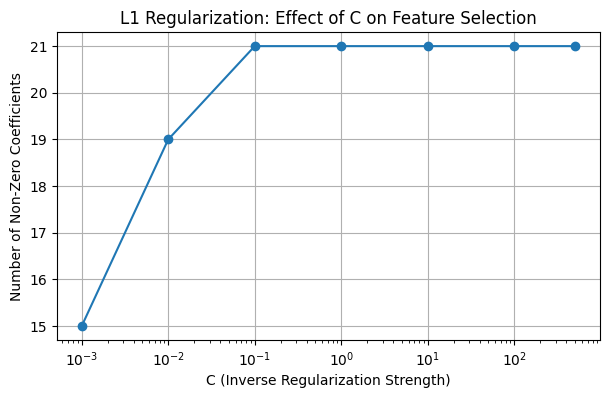

In [62]:

C_values = [0.001,0.01, 0.1, 1, 10, 100,500]

nonzero_counts = []


for C in C_values:
    
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        max_iter=10000,
        random_state=RANDOM_STATE
    )
    

    model.fit(X_train, y_train)

    nonzero_counts.append(np.sum(model.coef_ != 0))


plt.figure(figsize=(7,4))

plt.plot(
    C_values,
    nonzero_counts,
    marker="o"
)

plt.xscale("log")

plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Number of Non-Zero Coefficients")

plt.title(
    "L1 Regularization: Effect of C on Feature Selection"
)

plt.grid(True)
plt.show()

## Training On Model (Logistic Regression,  Random Forest,  Decision Tree)

In [63]:

models = {
    "Logistic Regression": LogisticRegression(
        penalty="l2", 
        C=1.0, 
        max_iter=10000, 
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, 
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE)
}

trained_models = {}

print("Starting training...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"✔️ {name} trained successfully.")

Starting training...



c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✔️ Logistic Regression trained successfully.
✔️ Random Forest trained successfully.
✔️ Decision Tree trained successfully.


In [65]:
eval_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    eval_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1),
        "Recall": recall_score(y_test, y_pred, pos_label=1),
        "F1-Score": f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

eval_df = pd.DataFrame(eval_results).set_index("Model").round(4)

print(eval_df)

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8782     0.8726  0.8426    0.8574   0.9294
Random Forest          0.9639     0.9731  0.9429    0.9578   0.9944
Decision Tree          0.9490     0.9410  0.9415    0.9413   0.9481


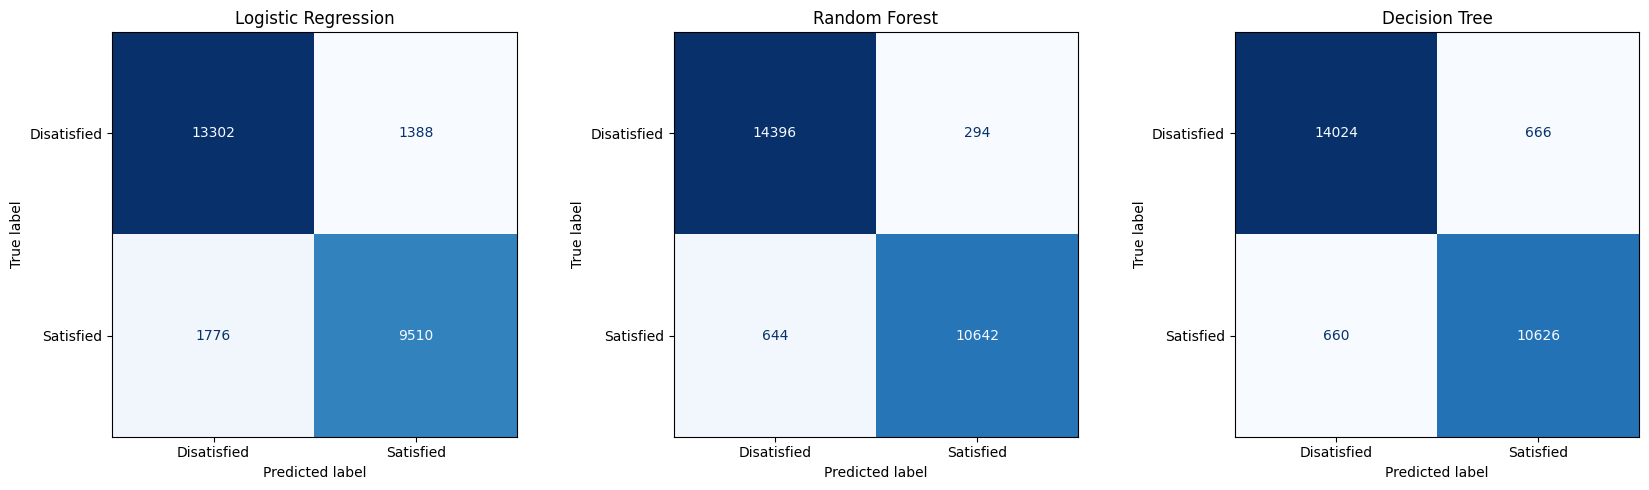

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Disatisfied", "Satisfied"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Roc Curve

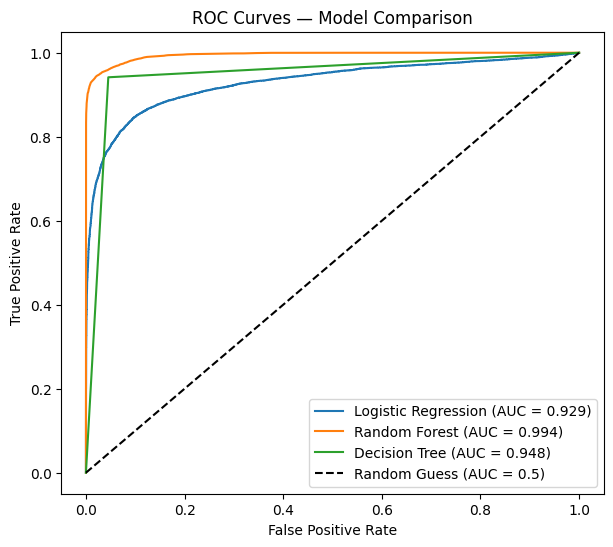

In [68]:
plt.figure(figsize=(7,6))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba,
        pos_label=1
    )

    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

## Full Classification Report

In [69]:
best_model_name = eval_df["F1-Score"].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model by F1-Score: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Neutral or Dissatisfied", "Satisfied"]))


Best model by F1-Score: Random Forest

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.94      0.96     11286

               accuracy                           0.96     25976
              macro avg       0.97      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



## Hyper Paramters

In [71]:
param_grid = {
    "C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
f1_custom = make_scorer(
    f1_score,
    pos_label=1
)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring=f1_custom,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Zain\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.8515


##   Final Model Performance  

In [73]:
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=== Final Tuned Model — Test Set Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final, pos_label=1):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")

=== Final Tuned Model — Test Set Performance ===
Accuracy:  0.8782
Precision: 0.8726
Recall:    0.8426
F1-Score:  0.8573
ROC-AUC:   0.9294
